# Week 2 - Day 4
## EDA Part 1: Distributions & Outliers

## 1. What is EDA?

Exploratory Data Analysis (EDA) is the systematic process of understanding a dataset before modeling.

EDA helps us understand:

- The structure of the dataset
- The distributions of variables
- Relationships between variables
- Potential data problems

EDA is an important step before machine learning because it helps identify problems in the data before they affect later results.

## 2. Import Libraries

Seaborn is used for statistical visualization and works directly with Pandas DataFrames.
Matplotlib is used to display the visualizations.
Pandas is used to load and inspect the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 3. Load the Dataset

The StudentsPerformance dataset is loaded into a Pandas DataFrame for exploratory analysis.

In [3]:
df = pd.read_csv("StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 4. Inspect the Dataset

Before performing EDA, we inspect the structure of the dataset and review its columns and data types.

In [4]:
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape:
(1000, 8)

Column names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 5. Identify Numeric and Categorical Variables

Different types of variables require different visualization techniques.

Numeric variables will be explored using histograms, box plots, and KDE plots.

Categorical variables will be explored using count plots.

In [6]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
categorical_columns = df.select_dtypes(exclude="number").columns.tolist()

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numeric columns:
['math score', 'reading score', 'writing score']

Categorical columns:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


## 6. Univariate Analysis

### 6.1 Histograms

A histogram shows the distribution of a numeric variable.

It helps us understand the shape and spread of the data and identify possible patterns or extreme values.

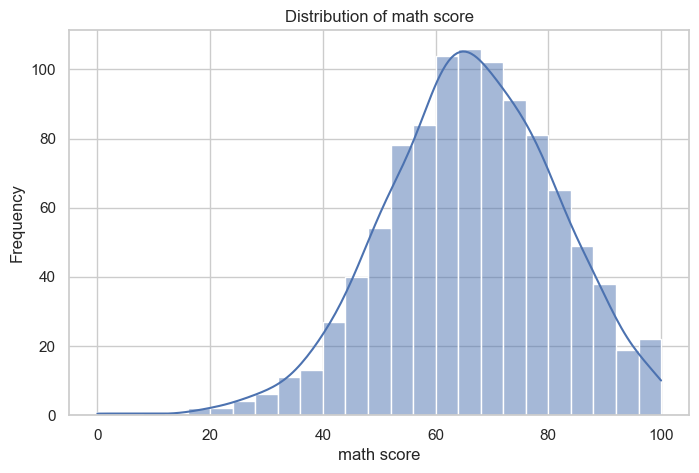

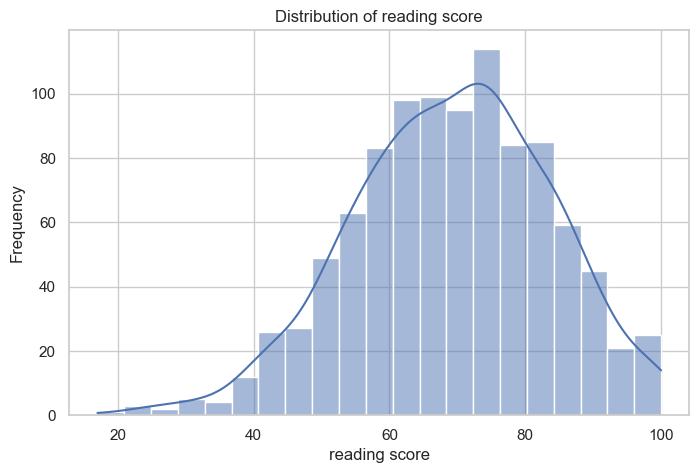

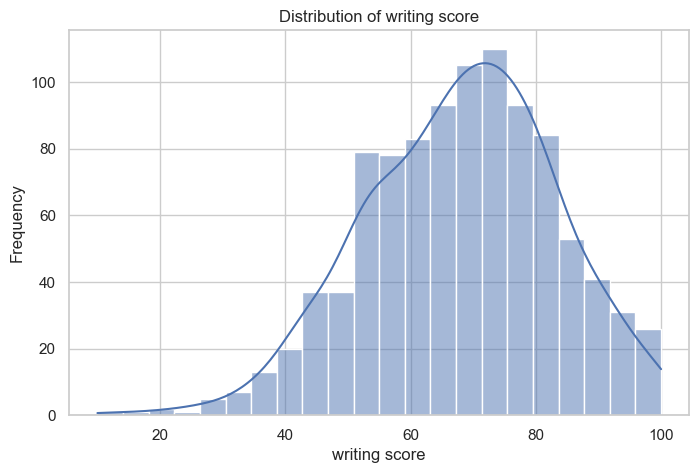

In [7]:
for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

### Histogram Observations

The histograms show the distributions of the numerical variables in the dataset.

The distributions should be examined for their overall shape, concentration of values, spread, and possible extreme observations.

### 6.2 Box Plots

A box plot summarizes a numeric variable using its median and quartiles.

It is also useful for identifying potential outliers that appear beyond the whiskers.

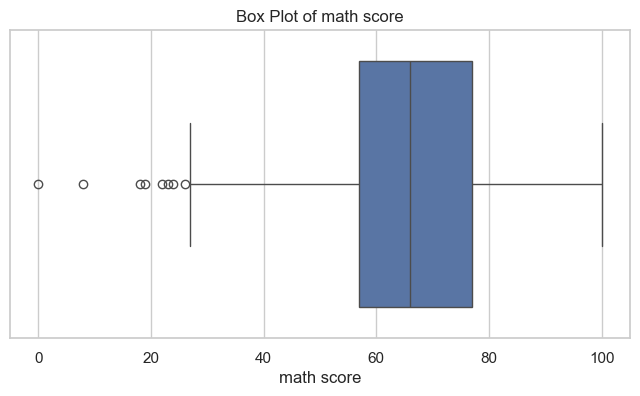

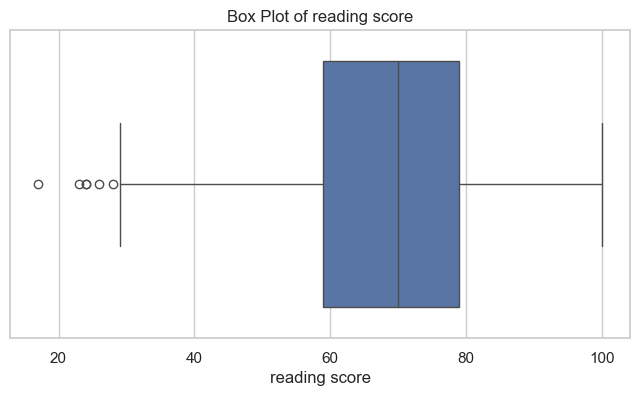

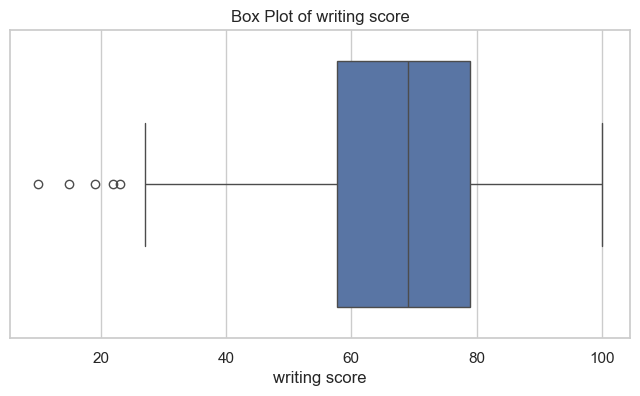

In [8]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=column)
    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.show()

### Box Plot Observations

The box plots show the central tendency and spread of each numerical variable.

Values appearing beyond the whiskers may represent potential outliers and will be investigated using the IQR method.

### 6.3 KDE Plots

A KDE plot provides a smoothed estimate of the distribution of a numerical variable.

It helps visualize the overall shape of the distribution.

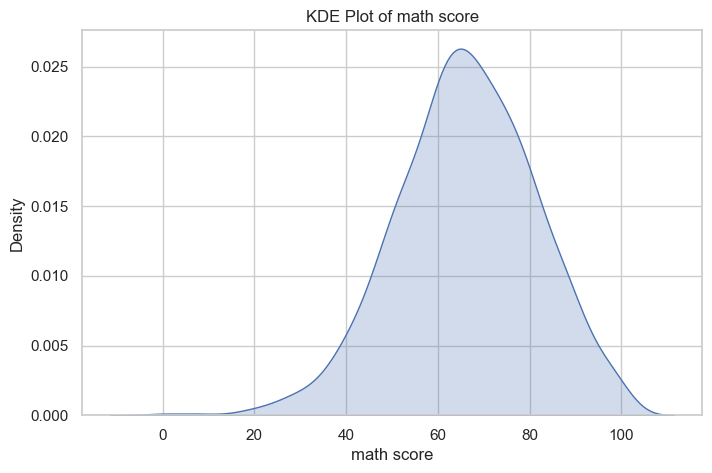

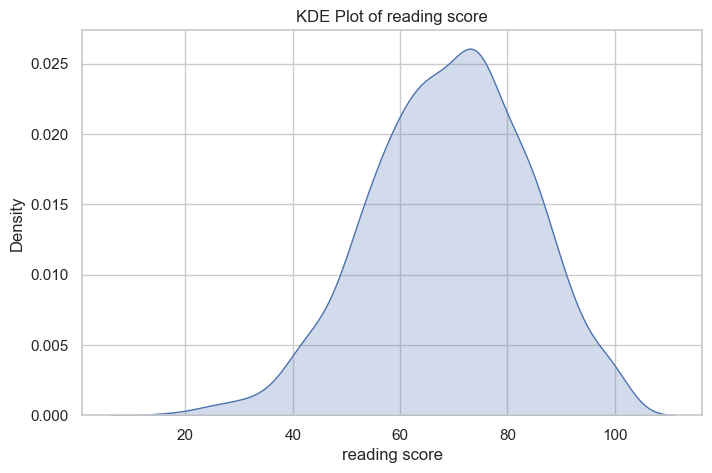

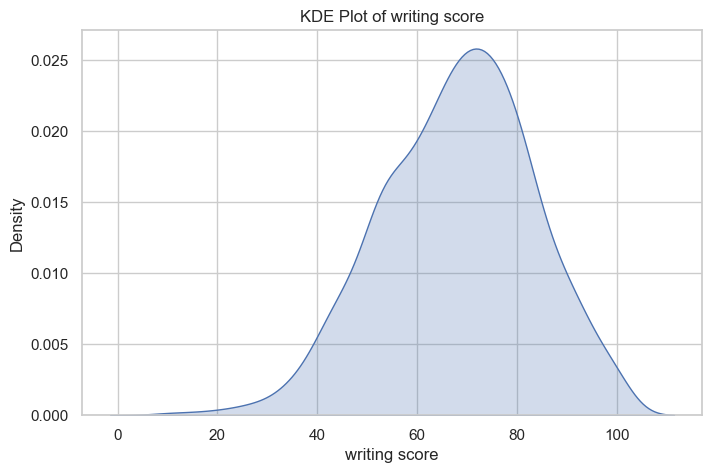

In [10]:
for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df, x=column, fill=True)
    plt.title(f"KDE Plot of {column}")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.show()

## 7. Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method is used to identify potential outliers.

The IQR is calculated as:

IQR = Q3 - Q1

The lower bound is:

Q1 - 1.5 × IQR

The upper bound is:

Q3 + 1.5 × IQR

Any value below the lower bound or above the upper bound is considered a potential outlier.

In [11]:
outlier_results = {}

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_results[column] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": len(outliers)
    }

outlier_results

{'math score': {'Q1': np.float64(57.0),
  'Q3': np.float64(77.0),
  'IQR': np.float64(20.0),
  'Lower Bound': np.float64(27.0),
  'Upper Bound': np.float64(107.0),
  'Number of Outliers': 8},
 'reading score': {'Q1': np.float64(59.0),
  'Q3': np.float64(79.0),
  'IQR': np.float64(20.0),
  'Lower Bound': np.float64(29.0),
  'Upper Bound': np.float64(109.0),
  'Number of Outliers': 6},
 'writing score': {'Q1': np.float64(57.75),
  'Q3': np.float64(79.0),
  'IQR': np.float64(21.25),
  'Lower Bound': np.float64(25.875),
  'Upper Bound': np.float64(110.875),
  'Number of Outliers': 5}}

In [12]:
outlier_summary = pd.DataFrame(outlier_results).T

outlier_summary

,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
math score,57.00,77.0,20.00,27.000,107.000,8.0
reading score,59.00,79.0,20.00,29.000,109.000,6.0
writing score,57.75,79.0,21.25,25.875,110.875,5.0


## 8. Inspect Potential Outliers

The IQR method identifies potential outliers.

These values should be investigated rather than automatically removed because they may represent genuine observations or possible data-entry problems.

In [13]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\nColumn: {column}")
    print(f"Number of potential outliers: {len(outliers)}")
    print(outliers[[column]].head())


Column: math score
Number of potential outliers: 8
     math score
17           18
59            0
145          22
338          24
466          26

Column: reading score
Number of potential outliers: 6
     reading score
59              17
76              26
211             28
327             23
596             24

Column: writing score
Number of potential outliers: 5
     writing score
59              10
76              22
327             19
596             15
980             23


## 9. Outlier Handling Decision

The potential outliers identified by the IQR method were investigated.

The values will not be removed automatically because an outlier may represent a genuine rare observation rather than an error.

The decision about handling the potential outliers should be based on the context of the dataset and the reason for the extreme values.

## 10. Categorical Variables

### Count Plots

A count plot shows the frequency of each category in a categorical variable.

It helps us identify dominant categories, rare categories, and possible class imbalance.

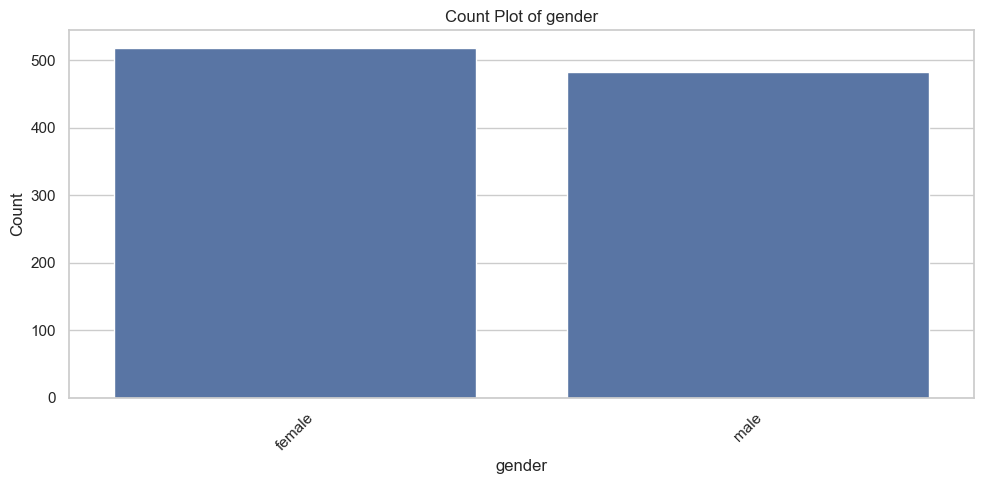

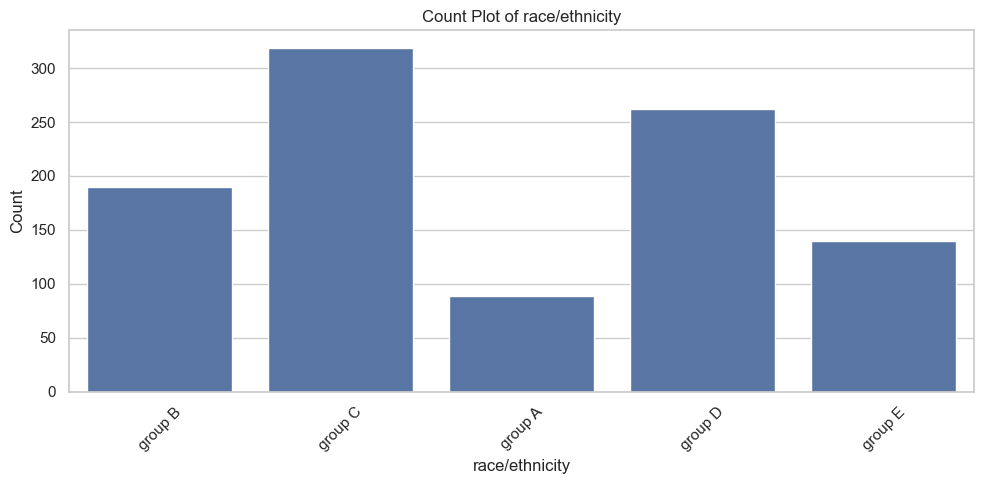

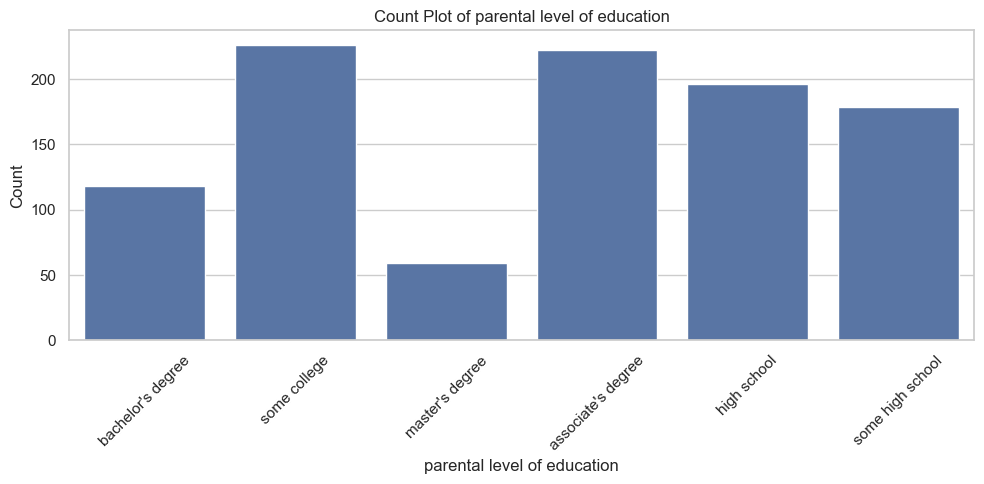

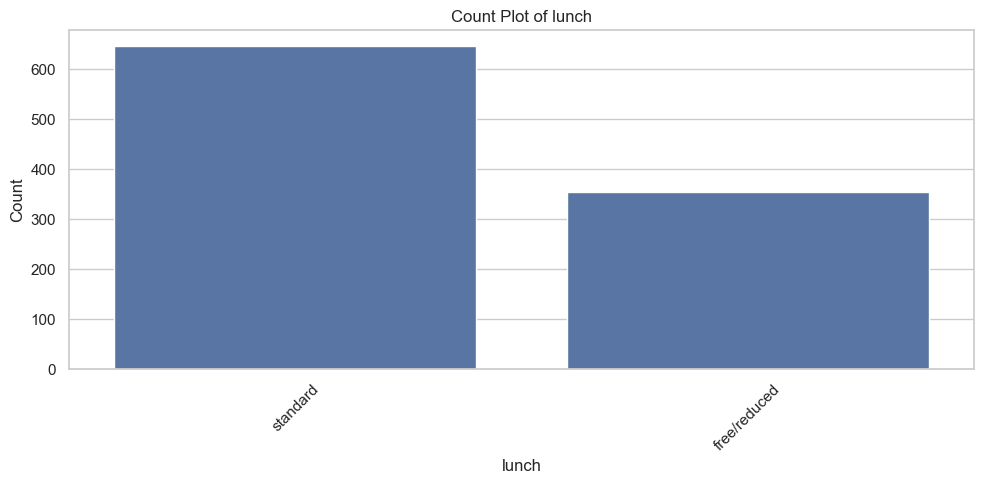

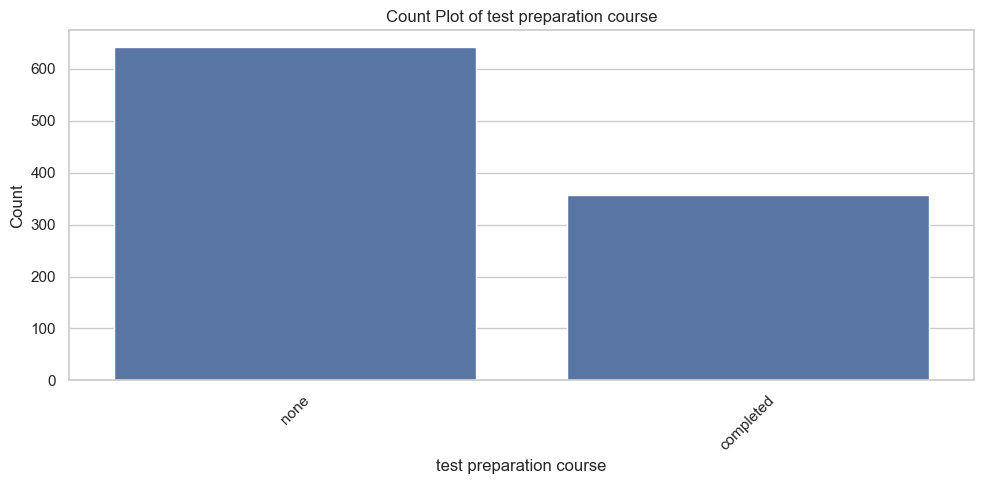

In [14]:
for column in categorical_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=column)
    plt.title(f"Count Plot of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Count Plot Observations

The count plots show the frequency of the categories in each categorical variable.

The distributions should be examined for dominant categories, rare categories, and possible class imbalance.

## 11. Day 4 Summary

In this notebook, Exploratory Data Analysis Part 1 was performed.

The analysis included:

- Understanding the purpose of EDA before modeling
- Using Seaborn for statistical visualization
- Performing univariate analysis
- Creating histograms for numeric variables
- Creating box plots to examine distributions and potential outliers
- Creating KDE plots to visualize distribution shapes
- Detecting potential outliers using the IQR method
- Creating count plots for categorical variables
- Documenting observations from the visualizations
- Making a decision about potential outliers